In [10]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics")

csv_paths = sorted(DATA_DIR.glob("*.csv"))
dataframes = {path.stem: pd.read_csv(path) for path in csv_paths}

df_all = pd.concat(
    [df.assign(flavor=name) for name, df in dataframes.items()],
    ignore_index=True,
)

csv_paths


[PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics/Electron.csv'),
 PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics/NC.csv'),
 PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics/Tau.csv')]

## Energy

Plot the `totalEnergy` distribution by flavor, treating every row in the truth-level CSV files as one event. The fourth panel is reserved for Muon and will be filled automatically once `Muon.csv` is available.


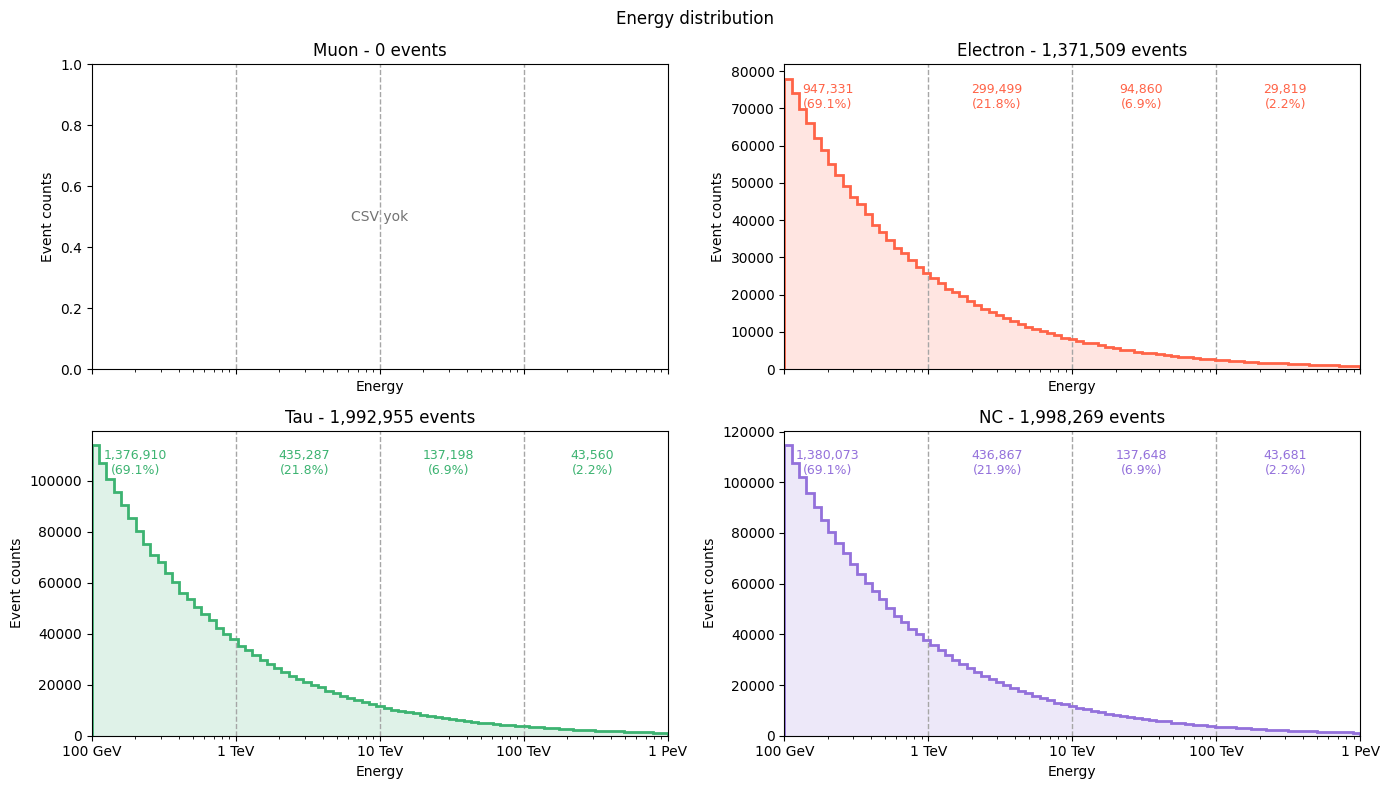

In [11]:
import matplotlib.pyplot as plt
import numpy as np

flavor_order = ["Muon", "Electron", "Tau", "NC"]
colors = {
    "Muon": "steelblue",
    "Electron": "tomato",
    "Tau": "mediumseagreen",
    "NC": "mediumpurple",
}

bins = np.logspace(np.log10(100), np.log10(1e6), 80)
band_edges = [100, 1e3, 1e4, 1e5, 1e6]
band_labels_x = [200, 3e3, 3e4, 3e5]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle("Energy distribution")

for ax, flavor in zip(axes.flat, flavor_order):
    df = dataframes.get(flavor)
    color = colors[flavor]

    ax.set_xscale("log")
    ax.set_xlim(100, 1e6)
    ax.set_xticks(band_edges)
    ax.set_xticklabels(["100 GeV", "1 TeV", "10 TeV", "100 TeV", "1 PeV"])
    ax.set_xlabel("Energy")
    ax.set_ylabel("Event counts")
    ax.grid(False)

    for edge in band_edges[1:-1]:
        ax.axvline(edge, color="0.65", linestyle="--", linewidth=1)

    if df is None or "totalEnergy" not in df:
        ax.set_title(f"{flavor} - 0 events")
        ax.text(0.5, 0.5, "CSV yok", transform=ax.transAxes, ha="center", va="center", color="0.45")
        continue

    energy = pd.to_numeric(df["totalEnergy"], errors="coerce").dropna()
    energy = energy[energy > 0]
    n_events = len(energy)

    ax.hist(energy, bins=bins, histtype="step", linewidth=2, color=color)
    ax.hist(energy, bins=bins, histtype="stepfilled", alpha=0.16, color=color)
    ax.set_title(f"{flavor} - {n_events:,} events")

    ymax = ax.get_ylim()[1]
    for left, right, x in zip(band_edges[:-1], band_edges[1:], band_labels_x):
        count = int(((energy >= left) & (energy < right)).sum())
        pct = 100 * count / n_events if n_events else 0
        ax.text(x, ymax * 0.94, f"{count:,}\n({pct:.1f}%)", ha="center", va="top", color=color, fontsize=9)

plt.tight_layout()
plt.show()


### Energy with E^-1.5 expectation

The same `totalEnergy` distributions are shown in log10 energy and normalized to their peak bin. The dashed curve shows the expected shape for an E^-1.5 spectrum in log-energy bins.


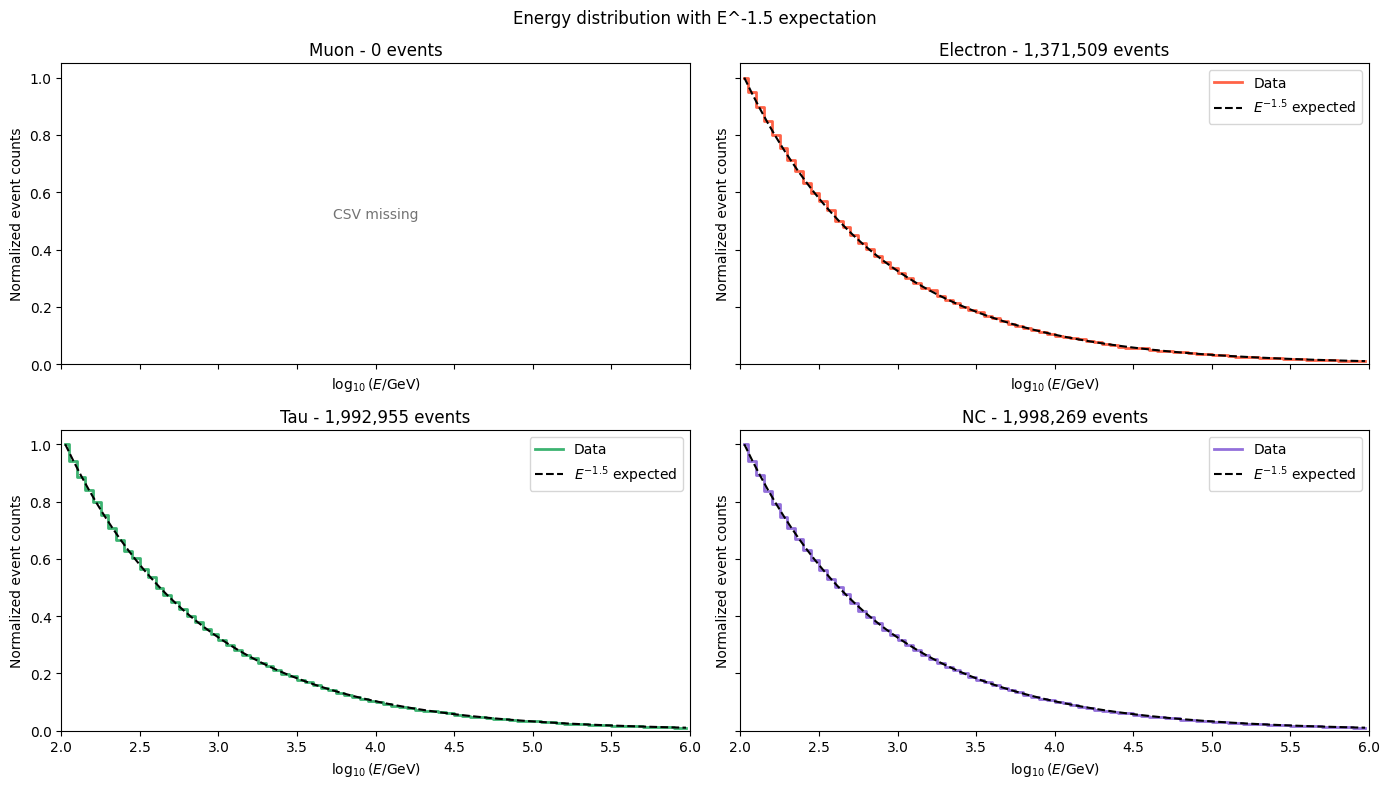

In [12]:
log_bins = np.linspace(2, 6, 81)
log_centers = 0.5 * (log_bins[:-1] + log_bins[1:])
expected = 10 ** (-0.5 * (log_centers - log_centers[0]))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle("Energy distribution with E^-1.5 expectation")

for ax, flavor in zip(axes.flat, flavor_order):
    df = dataframes.get(flavor)
    color = colors[flavor]

    ax.set_xlim(2, 6)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(r"$\log_{10}(E / \mathrm{GeV})$")
    ax.set_ylabel("Normalized event counts")
    ax.grid(False)

    if df is None or "totalEnergy" not in df:
        ax.set_title(f"{flavor} - 0 events")
        ax.text(0.5, 0.5, "CSV missing", transform=ax.transAxes, ha="center", va="center", color="0.45")
        continue

    energy = pd.to_numeric(df["totalEnergy"], errors="coerce").dropna()
    energy = energy[energy > 0]
    log_energy = np.log10(energy)
    counts, _ = np.histogram(log_energy, bins=log_bins)

    if counts.max() == 0:
        ax.set_title(f"{flavor} - 0 events")
        continue

    normalized = counts / counts.max()
    ax.step(log_centers, normalized, where="mid", linewidth=2, color=color, label="Data")
    ax.plot(log_centers, expected, "k--", linewidth=1.5, label=r"$E^{-1.5}$ expected")
    ax.set_title(f"{flavor} - {len(energy):,} events")
    ax.legend()

plt.tight_layout()
plt.show()


### ToDo: I can plot similar thing based only on triggered events

### ToDo: Zenith Distribution, Azimuth Distribution, Bjorken X, Bjorken Y, Vertex Position, ColumnDepth etc distributions

## Azimuth

Plot the azimuth distribution by flavor, treating every available row in the truth-level CSV files as one event.


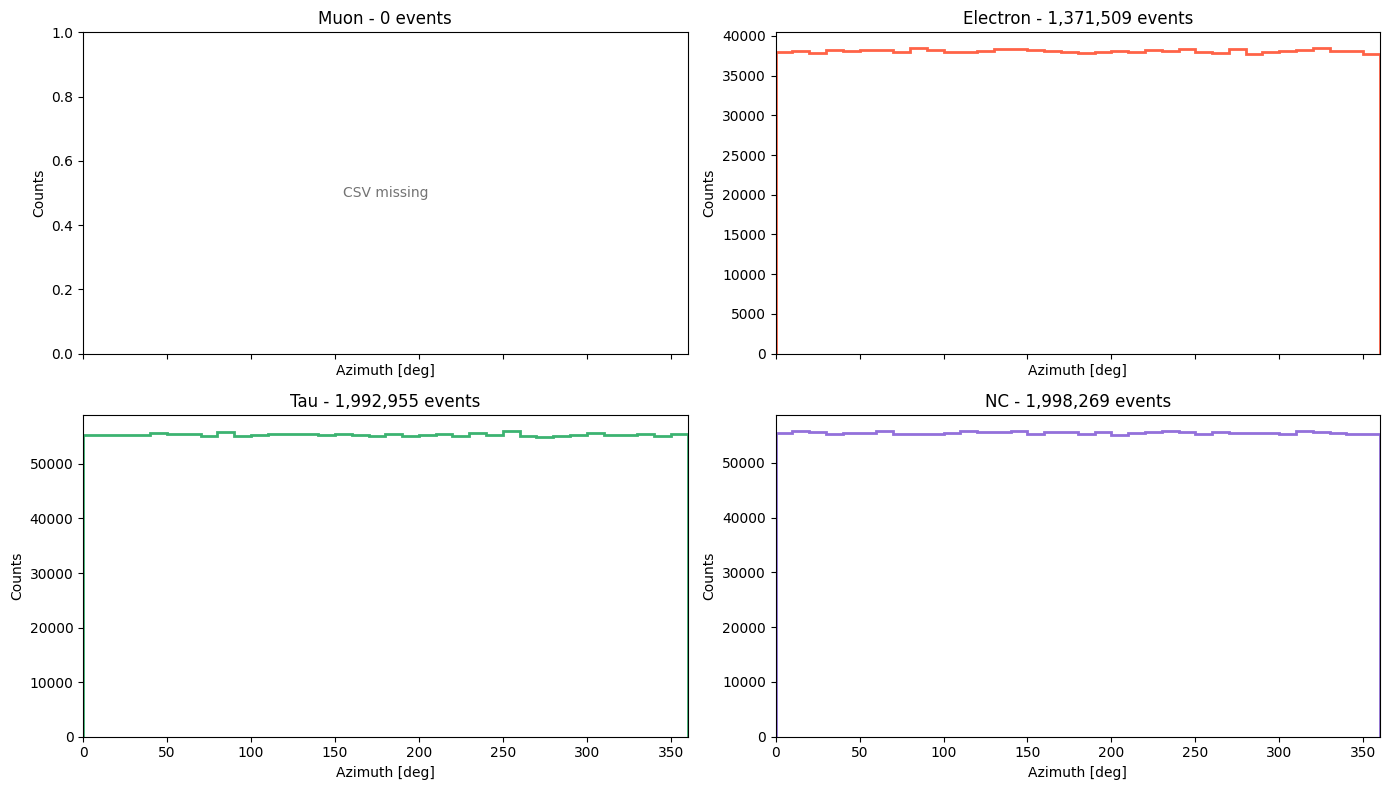

In [13]:
azimuth_bins = np.linspace(0, 360, 37)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, flavor in zip(axes.flat, flavor_order):
    df = dataframes.get(flavor)
    color = colors[flavor]

    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 50))
    ax.set_xlabel("Azimuth [deg]")
    ax.set_ylabel("Counts")
    ax.grid(False)

    if df is None or "azimuth" not in df:
        ax.set_title(f"{flavor} - 0 events")
        ax.text(0.5, 0.5, "CSV missing", transform=ax.transAxes, ha="center", va="center", color="0.45")
        continue

    azimuth = pd.to_numeric(df["azimuth"], errors="coerce").dropna()
    n_events = len(azimuth)

    if n_events == 0:
        ax.set_title(f"{flavor} - 0 events")
        continue

    if azimuth.max() <= 2 * np.pi + 1e-6:
        azimuth_deg = np.degrees(azimuth)
    else:
        azimuth_deg = azimuth
    azimuth_deg = azimuth_deg % 360

    ax.hist(azimuth_deg, bins=azimuth_bins, histtype="step", linewidth=2, color=color)
    ax.set_title(f"{flavor} - {n_events:,} events")

plt.tight_layout()
plt.show()


## Zenith

Plot the zenith distribution by flavor, treating every available row in the truth-level CSV files as one event.


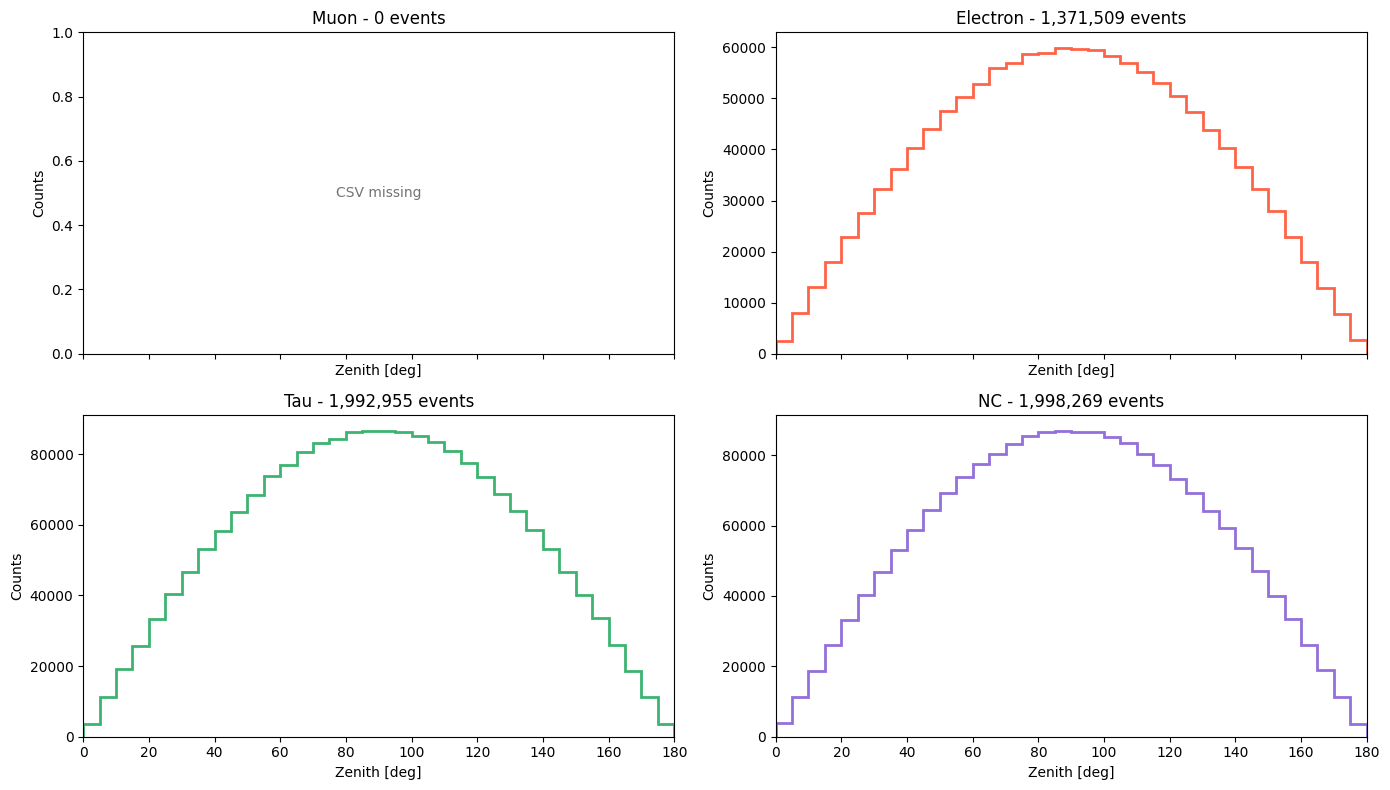

In [14]:
zenith_bins = np.linspace(0, 180, 37)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, flavor in zip(axes.flat, flavor_order):
    df = dataframes.get(flavor)
    color = colors[flavor]

    ax.set_xlim(0, 180)
    ax.set_xlabel("Zenith [deg]")
    ax.set_ylabel("Counts")
    ax.grid(False)

    if df is None or "zenith" not in df:
        ax.set_title(f"{flavor} - 0 events")
        ax.text(0.5, 0.5, "CSV missing", transform=ax.transAxes, ha="center", va="center", color="0.45")
        continue

    zenith = pd.to_numeric(df["zenith"], errors="coerce").dropna()
    n_events = len(zenith)

    if n_events == 0:
        ax.set_title(f"{flavor} - 0 events")
        continue

    if zenith.max() <= np.pi + 1e-6:
        zenith_deg = np.degrees(zenith)
    else:
        zenith_deg = zenith
    zenith_deg = zenith_deg[(zenith_deg >= 0) & (zenith_deg <= 180)]

    ax.hist(zenith_deg, bins=zenith_bins, histtype="step", linewidth=2, color=color)
    ax.set_title(f"{flavor} - {n_events:,} events")

plt.tight_layout()
plt.show()


## Bjorken x

Plot the Bjorken x distribution by flavor using `finalStateX`, treating every available row in the truth-level CSV files as one event.


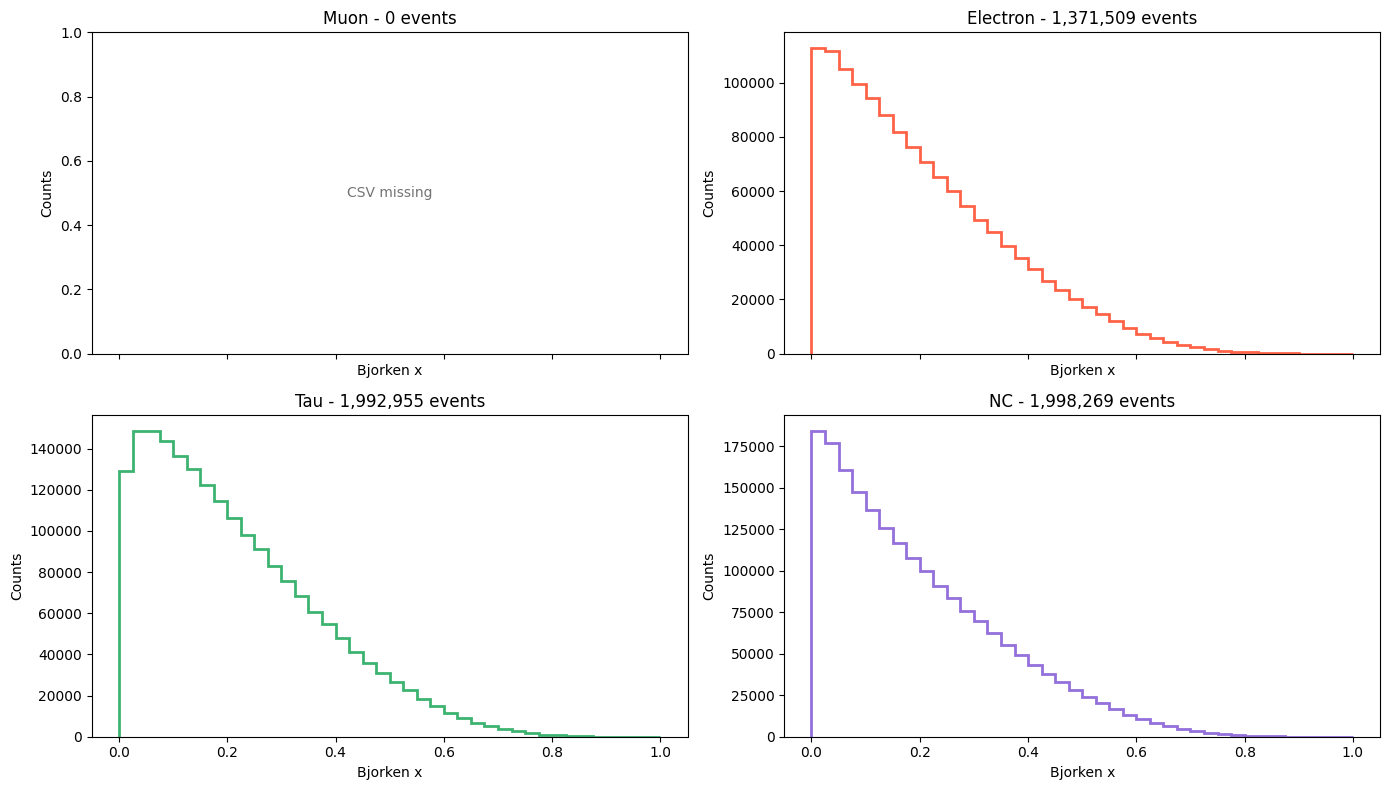

In [15]:
bjorken_x_bins = np.linspace(0, 1, 41)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, flavor in zip(axes.flat, flavor_order):
    df = dataframes.get(flavor)
    color = colors[flavor]

    ax.set_xlim(-0.05, 1.05)
    ax.set_xlabel("Bjorken x")
    ax.set_ylabel("Counts")
    ax.grid(False)

    if df is None or "finalStateX" not in df:
        ax.set_title(f"{flavor} - 0 events")
        ax.text(0.5, 0.5, "CSV missing", transform=ax.transAxes, ha="center", va="center", color="0.45")
        continue

    bjorken_x = pd.to_numeric(df["finalStateX"], errors="coerce").dropna()
    bjorken_x = bjorken_x[(bjorken_x >= 0) & (bjorken_x <= 1)]
    n_events = len(bjorken_x)

    if n_events == 0:
        ax.set_title(f"{flavor} - 0 events")
        continue

    ax.hist(bjorken_x, bins=bjorken_x_bins, histtype="step", linewidth=2, color=color)
    ax.set_title(f"{flavor} - {n_events:,} events")

plt.tight_layout()
plt.show()


## Bjorken y

Plot the Bjorken y distribution by flavor using `finalStateY`, treating every available row in the truth-level CSV files as one event.


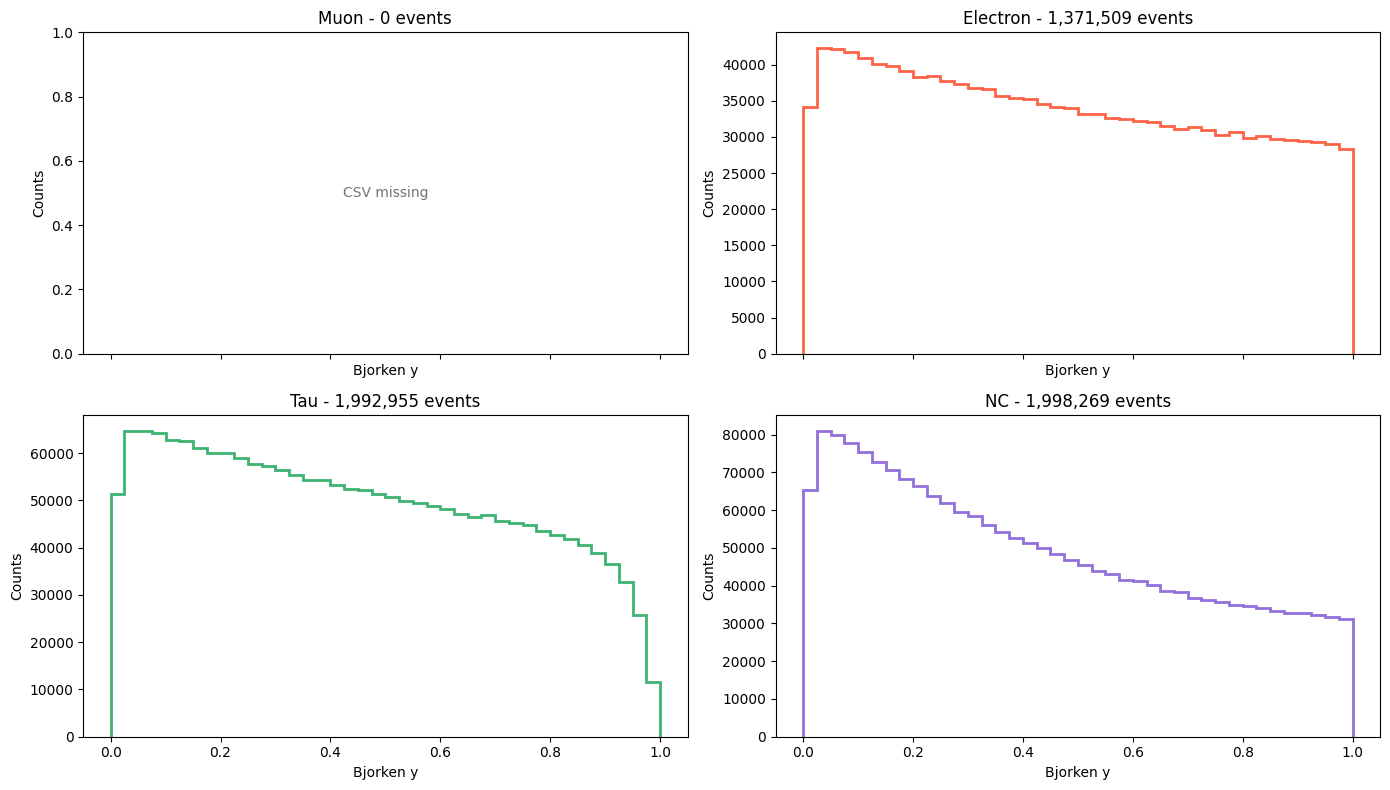

In [16]:
bjorken_y_bins = np.linspace(0, 1, 41)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, flavor in zip(axes.flat, flavor_order):
    df = dataframes.get(flavor)
    color = colors[flavor]

    ax.set_xlim(-0.05, 1.05)
    ax.set_xlabel("Bjorken y")
    ax.set_ylabel("Counts")
    ax.grid(False)

    if df is None or "finalStateY" not in df:
        ax.set_title(f"{flavor} - 0 events")
        ax.text(0.5, 0.5, "CSV missing", transform=ax.transAxes, ha="center", va="center", color="0.45")
        continue

    bjorken_y = pd.to_numeric(df["finalStateY"], errors="coerce").dropna()
    bjorken_y = bjorken_y[(bjorken_y >= 0) & (bjorken_y <= 1)]
    n_events = len(bjorken_y)

    if n_events == 0:
        ax.set_title(f"{flavor} - 0 events")
        continue

    ax.hist(bjorken_y, bins=bjorken_y_bins, histtype="step", linewidth=2, color=color)
    ax.set_title(f"{flavor} - {n_events:,} events")

plt.tight_layout()
plt.show()
